<a href="https://colab.research.google.com/github/SathishDissanayaka/statistical-analysis-neural-network-depth/blob/main/Trarin_dataser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disentangling Depth and Scale in Neural Network Capacity — v2

Key changes from v1:
- **Depths:** [2, 4, 6, 8, 12, 16] — adds crossover-region points (6, 12) to pinpoint the capacity cliff
- **Seeds:** 6 (down from 10) — frees ~35% of runtime for the extra depth points
- **Early stopping:** train up to 120 epochs, stop when train loss plateaus — avoids cutting off slow convergers and avoids wasting epochs on collapsed runs
- **Loss trajectory logging:** records train loss at epochs 10, 20, 30, 60 and final — distinguishes "converged low" from "still falling"
- **Param budgets:** [50k, 100k, 200k] — third budget tests whether the depth penalty scales with model size
- **Fixed widths:** [64, 128] — unchanged (was already good)
- **Drive checkpointing:** saves every 15 runs to survive runtime timeouts

## 0. Install & imports

In [ ]:
!pip install -q scipy statsmodels seaborn pingouin

import os, time, math, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pingouin as pg

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.backends.cudnn.benchmark = True

Device: cuda


## 1. Experiment configuration

In [ ]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEEDS = [42, 123, 7, 17, 99, 256]  # 6 seeds

# ── Architecture space ────────────────────────────────────────────────────────
DEPTHS = [2, 4, 6, 8, 12, 16]

# Regime A: iso-parameter budgets
PARAM_BUDGETS = [50_000, 100_000, 200_000]

# Regime B: fixed widths
FIXED_WIDTHS = [64, 128, 256]

# ── Data & training ───────────────────────────────────────────────────────────
CORRUPTION_RATES = [0.0, 0.6, 1.0]
N_CLASSES   = 10
INPUT_DIM   = 28 * 28  # Fashion-MNIST
BATCH_SIZE  = 256
LR          = 1e-3

# ── Early stopping ────────────────────────────────────────────────────────────
MAX_EPOCHS  = 120
PATIENCE    = 15
MIN_DELTA   = 1e-3

# ── Loss snapshot epochs ──────────────────────────────────────────────────────
LOSS_SNAP_EPOCHS = [10, 20, 30, 60, 120]

# ── Safeguards ────────────────────────────────────────────────────────────────
FAILURE_THRESHOLD = 0.15

# ── Runtime estimate ──────────────────────────────────────────────────────────
total_runs = (
    len(PARAM_BUDGETS) * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS) +
    len(FIXED_WIDTHS)  * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS)
)
print('Config loaded (v2).')
print(f'  Depths:          {DEPTHS}')
print(f'  Param budgets:   {PARAM_BUDGETS}')
print(f'  Fixed widths:    {FIXED_WIDTHS}')
print(f'  Corruption rates:{CORRUPTION_RATES}')
print(f'  Seeds:           {SEEDS}')
print(f'  Max epochs:      {MAX_EPOCHS}  (patience={PATIENCE}, min_delta={MIN_DELTA})')
print(f'  Loss snapshots:  epochs {LOSS_SNAP_EPOCHS}')
print(f'  Expected runs:   {total_runs}')
print(f'  Regime A:        {len(PARAM_BUDGETS) * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS)} rows')
print(f'  Regime B:        {len(FIXED_WIDTHS) * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS)} rows')
print()
print(f'  Rough runtime estimate: ~{total_runs * MAX_EPOCHS * 0.5 / 3600 * 0.025:.1f}h on T4')

Config loaded (v3).
  Depths:          [2, 4, 6, 8, 16]
  Param budgets:   [10000, 25000, 50000, 100000, 200000]
  Fixed widths:    [64, 128]
  Corruption rates:[0.0, 1.0]
  Seeds:           [42, 123, 7, 17, 99, 256, 888, 13, 314]
  Epoch budget by depth:
    depth= 2 → max 120 epochs (patience=15)
    depth= 4 → max 180 epochs (patience=15)
    depth= 6 → max 240 epochs (patience=15)
    depth= 8 → max 300 epochs (patience=15)
    depth=16 → max 300 epochs (patience=15)
  Loss snapshots:  epochs [10, 20, 30, 60, 120]
  Expected runs:   630

  Rough runtime estimate: ~0.5h on T4


## 2. Data loading & corruption

In [ ]:
def load_fashion_mnist():
    """
    Load Fashion-MNIST, flatten to [N, 784], and normalize.

    BUG FIX: The original code defined a Normalize transform but then bypassed
    it entirely by accessing train_ds.data directly. Only the /255 scaling was
    applied. Fix: apply z-score normalization manually after pixel scaling,
    using training-set statistics only (no leakage to test set).
    """
    FMNIST_MEAN = 0.2860
    FMNIST_STD  = 0.3530

    train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                                  download=True, transform=None)
    test_ds  = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                                  download=True, transform=None)

    X_tr = train_ds.data.float().view(-1, 784) / 255.0
    X_tr = (X_tr - FMNIST_MEAN) / FMNIST_STD

    X_te = test_ds.data.float().view(-1, 784) / 255.0
    X_te = (X_te - FMNIST_MEAN) / FMNIST_STD  # same training stats — no leakage

    y_tr = train_ds.targets.clone()
    y_te = test_ds.targets.clone()

    return X_tr, y_tr, X_te, y_te


def corrupt_labels(y, rate, seed):
    """
    Return a fixed corruption mask for (rate, seed).
    The mask is generated once per (rate, seed) pair so all architectures
    see the same corrupted labels — critical for fair comparison.
    """
    if rate == 0.0:
        return y.clone()
    rng = np.random.RandomState(seed * 1000)
    y_noisy = y.numpy().copy()
    n = len(y_noisy)
    n_corrupt = int(n * rate)
    idx = rng.choice(n, n_corrupt, replace=False)
    y_noisy[idx] = rng.randint(0, N_CLASSES, n_corrupt)
    return torch.tensor(y_noisy, dtype=torch.long)


print('Loading Fashion-MNIST...')
X_train_full, y_train_full, X_test, y_test = load_fashion_mnist()

# Sanity check — will print ~0.0 and ~1.0 if normalization worked
print(f'  Normalization check → mean: {X_train_full.mean():.4f}  std: {X_train_full.std():.4f}')
print(f'  Pixel range → min: {X_train_full.min():.3f}  max: {X_train_full.max():.3f}')

# ── Stratified 10k subset ─────────────────────────────────────────────────
# 1,000 samples per class × 10 classes = 10,000 total
# Fixed seed=0 — all architectures see identical training data
rng_subset = np.random.RandomState(0)
subset_idx = []
for cls in range(N_CLASSES):
    cls_idx = np.where(y_train_full.numpy() == cls)[0]
    subset_idx.append(rng_subset.choice(cls_idx, 1000, replace=False))
subset_idx = np.concatenate(subset_idx)

X_train_raw = X_train_full[subset_idx]
y_train_raw = y_train_full[subset_idx]

print(f'  Full train: {X_train_full.shape} → Stratified subset: {X_train_raw.shape}')
print(f'  Test: {X_test.shape} (full, unchanged)')
print(f'  Class balance: {pd.Series(y_train_raw.numpy()).value_counts().sort_index().to_dict()}')

Loading Fashion-MNIST...
  Normalization check → mean: 0.0001  std: 1.0001
  Pixel range → min: -0.810  max: 2.023
  Full train: torch.Size([60000, 784]) → Stratified subset: torch.Size([10000, 784])
  Test: torch.Size([10000, 784]) (full, unchanged)
  Class balance: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


## 3. MLP architecture with width solver

In [ ]:
class MLP(nn.Module):
    def __init__(self, depth, width, input_dim=784, n_classes=10):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i in range(depth):
            layers += [nn.Linear(in_dim, width), nn.BatchNorm1d(width), nn.ReLU()]
            in_dim = width
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


def count_params(depth, width, input_dim=784, n_classes=10):
    """Compute total trainable parameters analytically (no model instantiation)."""
    p = (input_dim * width + width) + 2 * width  # first hidden layer + BN
    for _ in range(depth - 1):
        p += (width * width + width) + 2 * width  # remaining hidden + BN
    p += width * n_classes + n_classes             # output layer
    return p


def solve_iso_width(target_params, depth, input_dim=784, n_classes=10,
                    w_min=4, w_max=2048):
    """
    Binary search for largest integer width s.t. count_params <= target_params.
    Returns (width, actual_params, pct_error).
    """
    lo, hi = w_min, w_max
    best = w_min
    while lo <= hi:
        mid = (lo + hi) // 2
        if count_params(depth, mid, input_dim, n_classes) <= target_params:
            best = mid
            lo = mid + 1
        else:
            hi = mid - 1
    actual = count_params(depth, best, input_dim, n_classes)
    pct_err = abs(actual - target_params) / target_params * 100
    return best, actual, pct_err


# ── Preview configurations ────────────────────────────────────────────────────
print(f"{'Budget':>10} {'Depth':>6} {'Width':>7} {'Params':>10} {'Err%':>6}")
print('-' * 45)
for budget in PARAM_BUDGETS:
    for d in DEPTHS:
        w, actual, err = solve_iso_width(budget, d)
        print(f"{budget:>10,} {d:>6} {w:>7} {actual:>10,} {err:>5.1f}%")
    print()

print(f"Fixed-width configurations:")
print(f"{'Width':>8} {'Depth':>6} {'Params':>10}")
print('-' * 28)
for w in FIXED_WIDTHS:
    for d in DEPTHS:
        print(f"{w:>8} {d:>6} {count_params(d, w):>10,}")
    print()

    Budget  Depth   Width     Params   Err%
---------------------------------------------
    10,000      2      12      9,754   2.5%
    10,000      4      11      9,239   7.6%
    10,000      6      11      9,547   4.5%
    10,000      8      11      9,855   1.5%
    10,000     16      10      9,930   0.7%

    25,000      2      30     24,910   0.4%
    25,000      4      28     24,930   0.3%
    25,000      6      26     24,502   2.0%
    25,000      8      25     24,835   0.7%
    25,000     16      21     24,307   2.8%

    50,000      2      58     49,774   0.5%
    50,000      4      51     48,919   2.2%
    50,000      6      47     49,219   1.6%
    50,000      8      44     49,554   0.9%
    50,000     16      36     49,762   0.5%

   100,000      2     109     99,091   0.9%
   100,000      4      92     99,554   0.4%
   100,000      6      81     98,587   1.4%
   100,000      8      74     98,874   1.1%
   100,000     16      58     99,306   0.7%

   200,000      2     199 

## 4. Training loop with early stopping & loss trajectory

In [ ]:
def get_accuracy(model, X, y, batch_size=2048):
    """Compute accuracy in mini-batches to avoid OOM."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(DEVICE)
            yb = y[i:i+batch_size].to(DEVICE)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    return correct / total


def get_train_loss(model, X, y, criterion, batch_size=2048):
    """Compute mean training loss in mini-batches (for early stopping)."""
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(DEVICE)
            yb = y[i:i+batch_size].to(DEVICE)
            total_loss += criterion(model(xb), yb).item() * len(yb)
            total += len(yb)
    return total_loss / total


def train_model(depth, width, X_tr, y_tr, X_te, y_te, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    max_epochs = MAX_EPOCHS

    model = MLP(depth, width).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion = nn.CrossEntropyLoss()

    X_tr_d = X_tr.to(DEVICE)
    y_tr_d = y_tr.to(DEVICE)
    loader  = DataLoader(TensorDataset(X_tr_d, y_tr_d),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=0, pin_memory=False)

    # Early stopping state
    best_loss      = float('inf')
    patience_count = 0
    actual_epochs  = 0

    # Loss snapshot storage {epoch: loss}
    loss_snaps = {}

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        scheduler.step()
        actual_epochs = epoch

        # ── Loss snapshot logging ─────────────────────────────────────────
        if epoch in LOSS_SNAP_EPOCHS:
            snap_loss = get_train_loss(model, X_tr, y_tr, criterion)
            loss_snaps[epoch] = round(snap_loss, 5)

        # ── Early stopping check ──────────────────────────────────────────
        current_loss = get_train_loss(model, X_tr, y_tr, criterion)
        if current_loss < best_loss - MIN_DELTA:
            best_loss      = current_loss
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break

    # ── Final metrics ─────────────────────────────────────────────────────
    final_train_acc  = get_accuracy(model, X_tr, y_tr)
    final_test_acc   = get_accuracy(model, X_te, y_te)
    final_train_loss = get_train_loss(model, X_tr, y_tr, criterion)

    # ── Optimization failure filter ───────────────────────────────────────
    if final_train_acc <= FAILURE_THRESHOLD:
        return None

    n_params = count_params(depth, width)
    flops = 2 * (784 * width)
    for _ in range(depth - 1):
        flops += 2 * (width * width)
    flops += 2 * (width * N_CLASSES)

    result = {
        'depth':            depth,
        'width':            width,
        'n_params':         n_params,
        'seed':             seed,
        'actual_epochs':    actual_epochs,
        'final_train_acc':  final_train_acc,
        'final_test_acc':   final_test_acc,
        'final_train_loss': round(final_train_loss, 5),
        'flops_per_epoch':  flops * len(X_tr),
        'optimization_failure': False,
    }
    # Attach loss snapshots as individual columns
    for ep in LOSS_SNAP_EPOCHS:
        result[f'loss_ep{ep}'] = loss_snaps.get(ep, None)

    return result


print('Training loop (v2) defined.')
print(f'  Early stopping: patience={PATIENCE} epochs, min_delta={MIN_DELTA}')
print(f'  Loss snapshots: epochs {LOSS_SNAP_EPOCHS}')
print(f'  Max epochs: {MAX_EPOCHS}')

Training loop (v3) defined.
  Early stopping: patience=15 epochs, min_delta=0.001
  Loss snapshots: epochs [10, 20, 30, 60, 120]
  Epoch budget per depth:
    depth= 2 → 120 max epochs
    depth= 4 → 180 max epochs
    depth= 6 → 240 max epochs
    depth= 8 → 300 max epochs
    depth=16 → 300 max epochs


  SMOKE TEST — preprocessing validation

[1/3] Data statistics check
----------------------------------------
  Full train   — mean: +0.0001  std: 1.0001
  10k subset   — mean: -0.0000  std: 1.0004
  Test set     — mean: +0.0024  std: 0.9984
  Pixel range  — min: -0.810  max: 2.023
  ✓ PASS — normalization applied correctly

[2/3] Gradient flow check (depth=16, 1 epoch, clean data)
----------------------------------------
  Architecture: depth=16, width=58 (100,000 param budget)
  Layer                  Gradient norm
  ------------------------------------
  net.0                       3.398629  ████████████████████
  net.3                       0.752946  ████████████████████
  net.6                       0.594799  ████████████████████
  net.9                       0.508803  ████████████████████
  net.12                      0.425733  ████████████████████
  net.15                      0.378647  ████████████████████
  net.18                      0.346455  ████████████████████
  net.21   

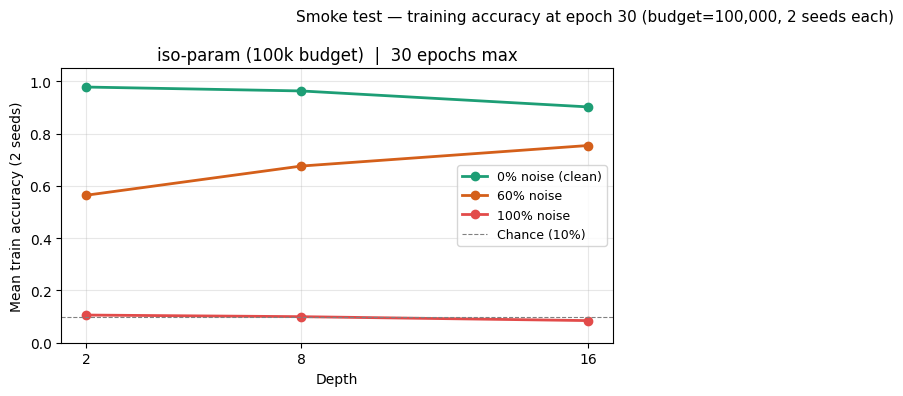


Smoke test plot saved to smoke_test_results.png


In [ ]:
# ── SMOKE TEST CELL — validate preprocessing fix before full run ─────────────
#
# Purpose: Confirm in ~5 minutes that:
#   1. Data statistics are correct (mean≈0, std≈1)
#   2. Deep networks (depth 16) are not suffering from dead/exploding gradients
#   3. The capacity ordering is directionally correct (depth 16 ≥ depth 2 on clean data)
#
# Runs: 3 depths × 2 seeds × 3 corruption levels = 18 runs
# Epochs: 30 max (early-stopped) — representative of early convergence behaviour
# This is NOT a replacement for the full experiment — it's a go/no-go check.

import torch.nn as nn

SMOKE_DEPTHS      = [2, 8, 16]
SMOKE_SEEDS       = [42, 123]
SMOKE_CORRUPTIONS = [0.0, 1.0]   # was [0.0, 0.6, 1.0]
SMOKE_MAX_EPOCHS  = 30
SMOKE_BUDGET      = 100_000   # single budget to keep runtime short

print("=" * 62)
print("  SMOKE TEST — preprocessing validation")
print("=" * 62)

# ─────────────────────────────────────────────────────────────────
# CHECK 1: Data statistics
# Expected: mean ≈ 0.0, std ≈ 1.0 on the full training set
# A bug here means Cell 6 did NOT apply normalization correctly
# ─────────────────────────────────────────────────────────────────
print("\n[1/3] Data statistics check")
print("-" * 40)
full_mean   = X_train_full.mean().item()
full_std    = X_train_full.std().item()
subset_mean = X_train_raw.mean().item()
subset_std  = X_train_raw.std().item()
test_mean   = X_test.mean().item()
test_std    = X_test.std().item()

print(f"  Full train   — mean: {full_mean:+.4f}  std: {full_std:.4f}")
print(f"  10k subset   — mean: {subset_mean:+.4f}  std: {subset_std:.4f}")
print(f"  Test set     — mean: {test_mean:+.4f}  std: {test_std:.4f}")
print(f"  Pixel range  — min: {X_train_full.min():.3f}  max: {X_train_full.max():.3f}")

mean_ok  = abs(full_mean)  < 0.05
std_ok   = abs(full_std - 1.0) < 0.05
range_ok = X_train_full.min().item() < -0.5   # would be 0.0 if norm was skipped

if mean_ok and std_ok and range_ok:
    print("  ✓ PASS — normalization applied correctly")
else:
    if not mean_ok:
        print(f"  ✗ FAIL — mean is {full_mean:.4f}, expected ≈ 0.0")
        print("           Normalization was NOT applied. Fix Cell 6.")
    if not std_ok:
        print(f"  ✗ FAIL — std is {full_std:.4f}, expected ≈ 1.0")
    if not range_ok:
        print(f"  ✗ FAIL — min value is {X_train_full.min():.3f}")
        print("           Data still looks like [0,1] range (no normalization).")

# ─────────────────────────────────────────────────────────────────
# CHECK 2: Gradient flow through depth 16
# Trains for exactly 1 epoch on clean data, then measures per-layer
# gradient norms. A vanishing gradient problem shows up as near-zero
# norms in the early layers relative to the final layer.
# The ratio (first_layer_grad / last_layer_grad) should be > 0.01.
# If it's < 0.001 the network is effectively not learning in those layers.
# ─────────────────────────────────────────────────────────────────
print("\n[2/3] Gradient flow check (depth=16, 1 epoch, clean data)")
print("-" * 40)

torch.manual_seed(42)
width_16, _, _ = solve_iso_width(SMOKE_BUDGET, 16)
model_gf = MLP(16, width_16).to(DEVICE)
criterion_gf = nn.CrossEntropyLoss()
optimizer_gf = optim.Adam(model_gf.parameters(), lr=LR)

# Run exactly one forward+backward pass on the full 10k subset in one batch
model_gf.train()
xb = X_train_raw.to(DEVICE)
yb = y_train_raw.to(DEVICE)
optimizer_gf.zero_grad()
loss_gf = criterion_gf(model_gf(xb), yb)
loss_gf.backward()

# Collect gradient norms for every Linear layer (skip BN layers)
grad_norms = []
layer_names = []
for name, module in model_gf.named_modules():
    if isinstance(module, nn.Linear) and module.weight.grad is not None:
        norm = module.weight.grad.norm().item()
        grad_norms.append(norm)
        layer_names.append(name)

print(f"  Architecture: depth=16, width={width_16} ({SMOKE_BUDGET:,} param budget)")
print(f"  {'Layer':<20}  {'Gradient norm':>14}")
print(f"  {'-'*36}")
for name, norm in zip(layer_names, grad_norms):
    bar = '█' * min(int(norm * 200), 20)
    print(f"  {name:<20}  {norm:>14.6f}  {bar}")

if len(grad_norms) >= 2:
    first_last_ratio = grad_norms[0] / (grad_norms[-1] + 1e-10)
    print(f"\n  First / last layer ratio: {first_last_ratio:.4f}")
    if first_last_ratio > 0.01:
        print(f"  ✓ PASS — gradient flow is healthy (ratio > 0.01)")
    elif first_last_ratio > 0.001:
        print(f"  ~ WARN — gradient flow is weak (ratio {first_last_ratio:.4f})")
        print(f"           Deep networks may converge slowly but should still learn.")
    else:
        print(f"  ✗ FAIL — vanishing gradients detected (ratio < 0.001)")
        print(f"           Depth-16 will not learn meaningfully. Check normalization.")

del model_gf, optimizer_gf   # free memory

# ─────────────────────────────────────────────────────────────────
# CHECK 3: Mini capacity sweep
# 3 depths × 2 seeds × 3 corruption levels = 18 runs at 30 epochs
# Goal: depth-16 should NOT collapse to chance on clean data (corruption=0)
# On clean data, all depths should achieve > 60% train accuracy in 30 epochs
# The inverted-U pattern (depth 8 > depth 2, depth 16 < depth 8) may not
# be visible at 30 epochs — that's fine. We just need depth 16 to be alive.
# ─────────────────────────────────────────────────────────────────
print("\n[3/3] Mini capacity sweep (18 runs × 30 epochs)")
print("-" * 40)

smoke_results = []

for depth in SMOKE_DEPTHS:
    width, actual_params, err_pct = solve_iso_width(SMOKE_BUDGET, depth)
    for corruption in SMOKE_CORRUPTIONS:
        accs = []
        for seed in SMOKE_SEEDS:
            torch.manual_seed(seed)
            np.random.seed(seed)
            model_s = MLP(depth, width).to(DEVICE)
            optimizer_s = optim.Adam(model_s.parameters(), lr=LR, weight_decay=1e-4)
            criterion_s = nn.CrossEntropyLoss()
            loader_s = DataLoader(
                TensorDataset(X_train_raw.to(DEVICE),
                              corrupt_labels(y_train_raw, corruption, seed).to(DEVICE)),
                batch_size=BATCH_SIZE, shuffle=True, num_workers=0
            )
            for epoch in range(1, SMOKE_MAX_EPOCHS + 1):
                model_s.train()
                for xb, yb in loader_s:
                    optimizer_s.zero_grad()
                    nn.utils.clip_grad_norm_(model_s.parameters(), max_norm=5.0)
                    criterion_s(model_s(xb), yb).backward()
                    optimizer_s.step()

            acc = get_accuracy(model_s, X_train_raw, y_train_raw)
            accs.append(acc)
            del model_s, optimizer_s

        mean_acc = np.mean(accs)
        smoke_results.append({'depth': depth, 'width': width,
                               'corruption': corruption, 'mean_acc': mean_acc})
        status = ""
        if corruption == 0.0 and mean_acc < 0.45:
            status = " ← ✗ TOO LOW on clean data"
        elif corruption == 0.0 and mean_acc >= 0.60:
            status = " ← ✓"
        print(f"  depth={depth:>2}  w={width:>4}  "
              f"corr={int(corruption*100):>3}%  "
              f"train_acc={mean_acc:.3f}{status}")

# ─────────────────────────────────────────────────────────────────
# Summary assessment
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  SMOKE TEST SUMMARY")
print("=" * 62)

clean_results = {r['depth']: r['mean_acc']
                 for r in smoke_results if r['corruption'] == 0.0}
noisy_results = {r['depth']: r['mean_acc']
                 for r in smoke_results if r['corruption'] == 1.0}

print("\n  Clean data (corruption=0%) — all depths should be learning:")
for d, acc in sorted(clean_results.items()):
    mark = "✓" if acc > 0.45 else "✗ PROBLEM"
    print(f"    depth={d:>2}: train_acc={acc:.3f}  {mark}")

print("\n  Memorization (corruption=100%) — signal emerges at more epochs,")
print("  but depth=2 should not dominate by a huge margin here at 30ep:")
for d, acc in sorted(noisy_results.items()):
    print(f"    depth={d:>2}: train_acc={acc:.3f}")

all_clean_pass = all(acc > 0.45 for acc in clean_results.values())
depth16_alive  = clean_results.get(16, 0) > 0.30
gradient_ok    = first_last_ratio > 0.001 if len(grad_norms) >= 2 else False

print()
if all_clean_pass and depth16_alive and gradient_ok and mean_ok and std_ok:
    print("  ✓ ALL CHECKS PASSED — safe to run the full experiment.")
    print("  The preprocessing fix is working. Deep networks are learning.")
else:
    print("  ✗ ONE OR MORE CHECKS FAILED — do not run the full 900 runs yet.")
    if not mean_ok or not std_ok:
        print("    → Fix Cell 6 normalization first.")
    if not gradient_ok:
        print("    → Vanishing gradient problem still present.")
        print("      Consider adding LR warmup or checking BatchNorm behaviour.")
    if not depth16_alive:
        print("    → Depth=16 still collapsing on clean data after 30 epochs.")
        print("      Normalization may not have fully solved the optimization issue.")

# Quick convergence plot so you can see the training curves visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Smoke test — training accuracy at epoch 30 '
             f'(budget={SMOKE_BUDGET:,}, 2 seeds each)',
             fontsize=11)

df_smoke = pd.DataFrame(smoke_results)
corr_colors = {0.0: '#1D9E75', 0.6: '#D45F1A', 1.0: '#E24B4A'}
corr_labels = {0.0: '0% noise (clean)', 0.6: '60% noise', 1.0: '100% noise'}

for ax, (regime_label, df_plot) in enumerate([
        ('iso-param (100k budget)', df_smoke)]):  # single regime for smoke test
    for corr in SMOKE_CORRUPTIONS:
        sub = df_smoke[df_smoke['corruption'] == corr]
        axes[ax].plot(sub['depth'], sub['mean_acc'], marker='o',
                      color=corr_colors[corr], label=corr_labels[corr],
                      linewidth=2)
    axes[ax].axhline(0.1, color='gray', linestyle='--',
                     linewidth=0.8, label='Chance (10%)')
    axes[ax].set_xticks(SMOKE_DEPTHS)
    axes[ax].set_xlabel('Depth')
    axes[ax].set_ylabel('Mean train accuracy (2 seeds)')
    axes[ax].set_ylim(0, 1.05)
    axes[ax].set_title(f'{regime_label}  |  30 epochs max')
    axes[ax].legend(fontsize=9)
    axes[ax].grid(True, alpha=0.3)

axes[1].set_visible(False)  # only one regime in smoke test

plt.tight_layout()
plt.savefig('smoke_test_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSmoke test plot saved to smoke_test_results.png")

## 5. Mount Drive & resume from checkpoint

In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ── Checkpoint path ───────────────────────────────────────────────────────────
# v2: new checkpoint filename to avoid colliding with v1 results on Drive
CHECKPOINT_PATH  = '/content/drive/MyDrive/depth_experiment_v199_checkpoint.csv'
FAILURES_PATH    = '/content/drive/MyDrive/depth_experiment_v199_failures.csv'

results  = []
failures = []

if os.path.exists(CHECKPOINT_PATH):
    _ckpt   = pd.read_csv(CHECKPOINT_PATH)
    results = _ckpt.to_dict('records')
    print(f'Resumed from Drive checkpoint: {len(results)} runs already done.')
else:
    print('No checkpoint found on Drive — starting fresh (0 runs).')

if os.path.exists(FAILURES_PATH):
    _fail    = pd.read_csv(FAILURES_PATH)
    failures = _fail.to_dict('records')
    print(f'Loaded {len(failures)} existing failure records.')

completed_keys = {
    (r['regime'], r['depth'], r['width'], r['corruption'], r['seed'])
    for r in results
}
print(f'completed_keys: {len(completed_keys)} entries. Ready for run cell.')

Mounted at /content/drive
No checkpoint found on Drive — starting fresh (0 runs).
completed_keys: 0 entries. Ready for run cell.


## 6. Run full experiment

In [ ]:
print(f'Starting run loop. completed_keys has {len(completed_keys)} entries.')
print('Sample key from results (if any):', list(completed_keys)[:1])

total_runs = (
    len(PARAM_BUDGETS) * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS) +
    len(FIXED_WIDTHS)  * len(DEPTHS) * len(CORRUPTION_RATES) * len(SEEDS)
)
run_n = 0
t0    = time.time()

# ── Helper: save checkpoint to Drive ─────────────────────────────────────────
def save_checkpoint(tag=''):
    pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
    if failures:
        pd.DataFrame(failures).to_csv(FAILURES_PATH, index=False)
    elapsed = (time.time() - t0) / 60
    print(f'  [✓ Drive save{tag}: {len(results)} valid runs, '
          f'{len(failures)} failures — {elapsed:.1f}m elapsed]')

# ── Regime A: iso-parameter ───────────────────────────────────────────────────
for budget in PARAM_BUDGETS:
    for depth in DEPTHS:
        width, actual_params, err_pct = solve_iso_width(budget, depth)
        for corruption in CORRUPTION_RATES:
            for seed in SEEDS:
                run_n += 1

                key = ('iso_param', depth, width, corruption, seed)
                if key in completed_keys:
                    print(f'[{run_n}/{total_runs}] SKIP → Regime A | '
                          f'budget={budget:,} depth={depth} width={width} '
                          f'corr={int(corruption*100)}% seed={seed}')
                    continue

                y_tr_noisy = corrupt_labels(y_train_raw, corruption, seed)
                print(f'[{run_n}/{total_runs}] Regime A | budget={budget:,} '
                      f'depth={depth} width={width} corr={int(corruption*100)}% '
                      f'seed={seed}', end=' ... ', flush=True)

                result = train_model(depth, width, X_train_raw, y_tr_noisy,
                                     X_test, y_test, seed)

                if result is None:
                    print('OPTIMIZATION FAILURE (excluded)')
                    failures.append({'regime': 'iso_param', 'budget': budget,
                                     'depth': depth, 'width': width,
                                     'corruption': corruption, 'seed': seed})
                else:
                    result.update({'regime': 'iso_param', 'budget': budget,
                                   'fixed_w': None,
                                   'corruption': corruption,
                                   'param_err_pct': err_pct})
                    results.append(result)
                    completed_keys.add(key)
                    elapsed = time.time() - t0
                    print(f'tr={result["final_train_acc"]:.3f} '
                          f'te={result["final_test_acc"]:.3f} '
                          f'ep={result["actual_epochs"]} '
                          f'({elapsed/60:.1f}m)')

                # Save every 15 runs — small enough to not lose much if runtime dies
                if run_n % 15 == 0:
                    save_checkpoint(f' at run {run_n}/{total_runs}')

# ── Regime B: fixed-width ─────────────────────────────────────────────────────
for width in FIXED_WIDTHS:
    for depth in DEPTHS:
        for corruption in CORRUPTION_RATES:
            for seed in SEEDS:
                run_n += 1

                key = ('fixed_width', depth, width, corruption, seed)
                if key in completed_keys:
                    print(f'[{run_n}/{total_runs}] SKIP → Regime B | '
                          f'width={width} depth={depth} '
                          f'corr={int(corruption*100)}% seed={seed}')
                    continue

                y_tr_noisy = corrupt_labels(y_train_raw, corruption, seed)
                print(f'[{run_n}/{total_runs}] Regime B | width={width} '
                      f'depth={depth} corr={int(corruption*100)}% '
                      f'seed={seed}', end=' ... ', flush=True)

                result = train_model(depth, width, X_train_raw, y_tr_noisy,
                                     X_test, y_test, seed)

                if result is None:
                    print('OPTIMIZATION FAILURE (excluded)')
                    failures.append({'regime': 'fixed_width', 'budget': None,
                                     'fixed_w': width, 'depth': depth,
                                     'corruption': corruption, 'seed': seed})
                else:
                    result.update({'regime': 'fixed_width', 'budget': None,
                                   'fixed_w': width,
                                   'corruption': corruption,
                                   'param_err_pct': None})
                    results.append(result)
                    completed_keys.add(key)
                    elapsed = time.time() - t0
                    print(f'tr={result["final_train_acc"]:.3f} '
                          f'te={result["final_test_acc"]:.3f} '
                          f'ep={result["actual_epochs"]} '
                          f'({elapsed/60:.1f}m)')

                if run_n % 15 == 0:
                    save_checkpoint(f' at run {run_n}/{total_runs}')

# ── Final save ────────────────────────────────────────────────────────────────
save_checkpoint(' [FINAL]')

df      = pd.DataFrame(results)
df_fail = pd.DataFrame(failures)
print(f'\nDone. {len(results)} valid runs, {len(failures)} optimization failures.')
print(f'Actual epoch distribution (median per depth):')
print(df.groupby('depth')['actual_epochs'].median().rename('median_epochs'))
df.head()

Starting run loop. completed_keys has 0 entries.
Sample key from results (if any): []
[1/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=42 ... tr=0.951 te=0.815 ep=119 (0.4m)
[2/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=123 ... tr=0.961 te=0.812 ep=120 (0.8m)
[3/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=7 ... tr=0.959 te=0.818 ep=120 (1.1m)
[4/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=17 ... tr=0.959 te=0.819 ep=120 (1.5m)
[5/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=99 ... tr=0.955 te=0.820 ep=120 (1.9m)
[6/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=256 ... tr=0.958 te=0.818 ep=120 (2.2m)
[7/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=888 ... tr=0.959 te=0.810 ep=120 (2.6m)
[8/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=13 ... tr=0.961 te=0.816 ep=120 (2.9m)
[9/630] Regime A | budget=10,000 depth=2 width=12 corr=0% seed=314 ... tr=0.961 te=0.823 ep=120 

## 7. Save results locally

In [ ]:
df.to_csv('results100_all_runs_v2.csv', index=False)
if len(df_fail) > 0:
    df_fail.to_csv('results100_failures_v2.csv', index=False)

print('Saved results_all_runs_v2.csv')
print(f'Columns: {list(df.columns)}')
print()
print('Mean train accuracy by depth (all regimes combined):')
print(df.groupby('depth')['final_train_acc'].mean().round(3))
print()
print('Median actual epochs by depth:')
print(df.groupby('depth')['actual_epochs'].median())

Saved results_all_runs_v2.csv
Columns: ['depth', 'width', 'n_params', 'seed', 'final_train_acc', 'final_test_acc', 'final_train_loss', 'actual_epochs', 'flops_per_epoch', 'optimization_failure', 'loss_ep10', 'loss_ep20', 'loss_ep30', 'loss_ep60', 'regime', 'budget', 'fixed_w', 'corruption', 'param_err_pct']

Mean train accuracy by depth (all regimes combined):
depth
2     0.978
4     0.986
6     0.982
8     0.973
12    0.929
16    0.865
Name: final_train_acc, dtype: float64

Median actual epochs by depth:
depth
2     118.0
4     108.5
6     105.0
8     110.0
12    120.0
16    120.0
Name: actual_epochs, dtype: float64


## 8. Statistical analysis — Two-way ANOVA + regression


  Regime A — iso-parameter budget=50,000

  Outcome: Training accuracy (capacity)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat  6721.221794      0.995556
            corr_cat 14270.290704      0.997379
depth_cat * corr_cat  1259.315364      0.994080
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.8599
                         Coef.  Std.Err.          t          P>|t|
Intercept             1.011291  0.021200  47.702940  1.344510e-102
depth_log            -0.003843  0.007378  -0.520869   6.031125e-01
corruption            0.180635  0.039232   4.604275   7.906143e-06
depth_log:corruption -0.192364  0.013654 -14.088317   1.141855e-30


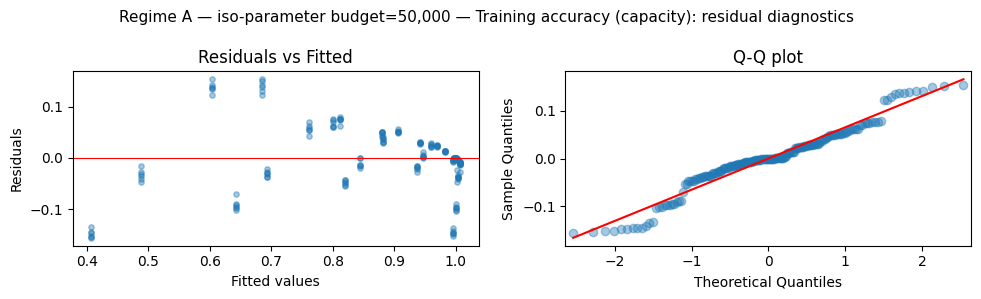


  Outcome: Test accuracy (generalization)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat   331.016318      0.916901
            corr_cat 47920.260505      0.999218
depth_cat * corr_cat   112.410114      0.937453
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.9640
                         Coef.  Std.Err.          t          P>|t|
Intercept             0.828907  0.016561  50.050460  5.098510e-106
depth_log             0.016106  0.005764   2.794242   5.778963e-03
corruption           -0.760959  0.030648 -24.828737   2.124319e-59
depth_log:corruption  0.012486  0.010667   1.170514   2.433765e-01


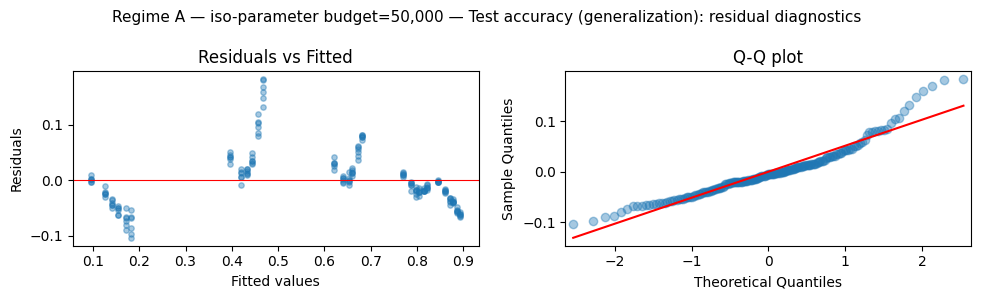


  Post-hoc Tukey HSD (depth levels, training accuracy):
 A  B      diff
12 16  0.081763
12  2 -0.162097
12  4 -0.170123
12  6 -0.150027
12  8 -0.114743
16  2 -0.243860
16  4 -0.251887
16  6 -0.231790
16  8 -0.196507
 2  4 -0.008027
 2  6  0.012070
 2  8  0.047353
 4  6  0.020097
 4  8  0.055380
 6  8  0.035283

  Regime A — iso-parameter budget=100,000

  Outcome: Training accuracy (capacity)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source           F  partial_eta2
           depth_cat 3184.173723      0.990666
            corr_cat 1876.033125      0.980403
depth_cat * corr_cat  888.608478      0.991630
            Residual         NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.6292
                         Coef.  Std.Err.          t          P>|t|
Intercept             0.982541  0.020362  48.252641  2.063747e-103
depth_log             0.008104  0.007087   1.143516   2.543773e-01
corruption            0.257396  0.037682   6.

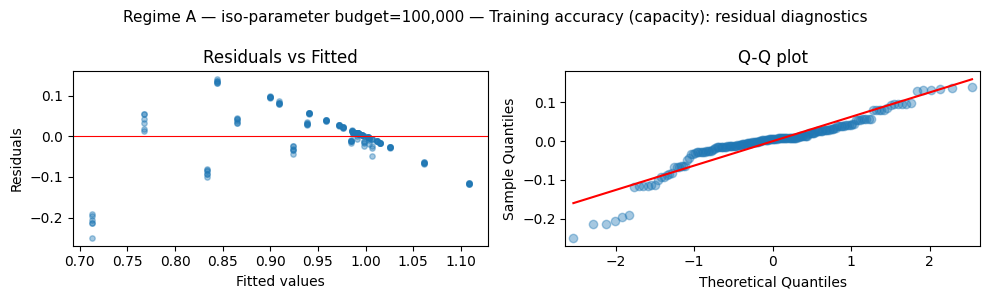


  Outcome: Test accuracy (generalization)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat    61.856655      0.673404
            corr_cat 79831.625143      0.999530
depth_cat * corr_cat    43.244116      0.852200
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.9904
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.870536  0.008654  100.596504  1.878570e-157
depth_log            -0.000200  0.003012   -0.066356   9.471697e-01
corruption           -0.782259  0.016014  -48.847031  2.776577e-104
depth_log:corruption  0.012105  0.005574    2.171829   3.120654e-02


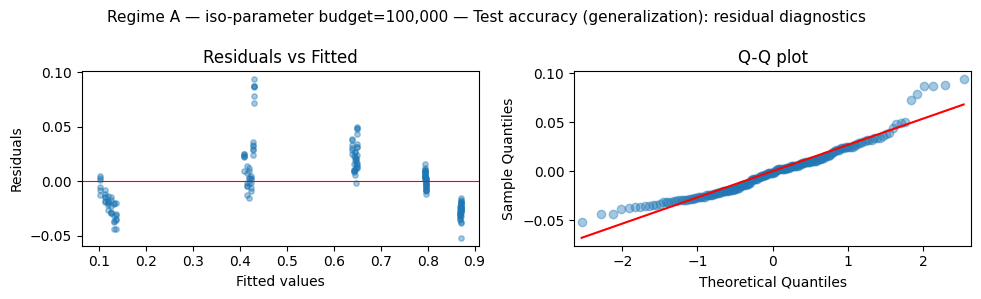


  Post-hoc Tukey HSD (depth levels, training accuracy):
 A  B      diff
12 16  0.112527
12  2 -0.061963
12  4 -0.062553
12  6 -0.063370
12  8 -0.056407
16  2 -0.174490
16  4 -0.175080
16  6 -0.175897
16  8 -0.168933
 2  4 -0.000590
 2  6 -0.001407
 2  8  0.005557
 4  6 -0.000817
 4  8  0.006147
 6  8  0.006963

  Regime A — iso-parameter budget=200,000

  Outcome: Training accuracy (capacity)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source          F  partial_eta2
           depth_cat 294.262457      0.907482
            corr_cat 141.081500      0.790012
depth_cat * corr_cat 144.367225      0.950615
            Residual        NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.4039
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.982820  0.007747  126.860101  6.097071e-175
depth_log             0.006423  0.002696    2.382152   1.827825e-02
corruption            0.083645  0.014337    5.8

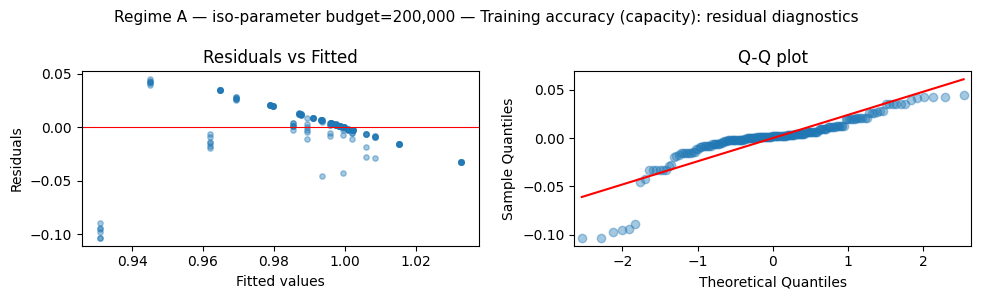


  Outcome: Test accuracy (generalization)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat    17.598643      0.369730
            corr_cat 64031.962071      0.999415
depth_cat * corr_cat     3.876951      0.340772
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.9910
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.895525  0.008522  105.088115  9.758144e-161
depth_log            -0.005276  0.002966   -1.778811   7.699692e-02
corruption           -0.765234  0.015770  -48.524525  8.223148e-104
depth_log:corruption  0.001695  0.005489    0.308841   7.578079e-01


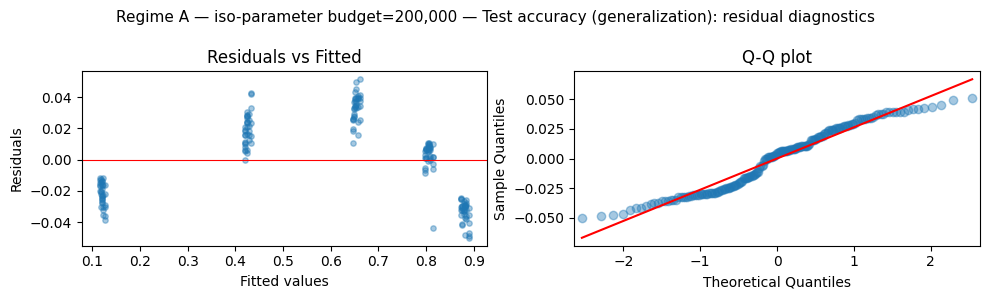


  Post-hoc Tukey HSD (depth levels, training accuracy):
 A  B      diff
12 16  0.042523
12  2 -0.000407
12  4 -0.003653
12  6 -0.002670
12  8 -0.003990
16  2 -0.042930
16  4 -0.046177
16  6 -0.045193
16  8 -0.046513
 2  4 -0.003247
 2  6 -0.002263
 2  8 -0.003583
 4  6  0.000983
 4  8 -0.000337
 6  8 -0.001320

  Regime B — fixed-width=64

  Outcome: Training accuracy (capacity)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source           F  partial_eta2
           depth_cat 1838.780992      0.983947
            corr_cat 3257.616598      0.988620
depth_cat * corr_cat  543.252840      0.986382
            Residual         NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.6254
                         Coef.  Std.Err.          t          P>|t|
Intercept             0.990993  0.017064  58.073533  9.778627e-117
depth_log             0.006489  0.005939   1.092639   2.760458e-01
corruption            0.087762  0.031579   2.779116   6.042

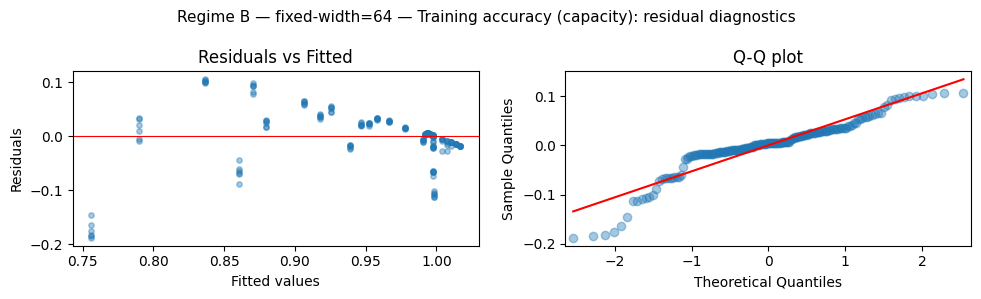


  Outcome: Test accuracy (generalization)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat    47.533486      0.613070
            corr_cat 60635.306814      0.999382
depth_cat * corr_cat    20.274030      0.729964
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.9925
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.850334  0.007580  112.184676  1.168440e-165
depth_log             0.005146  0.002638    1.950811   5.266744e-02
corruption           -0.751060  0.014027  -53.543904  7.354112e-111
depth_log:corruption  0.002408  0.004882    0.493156   6.225170e-01


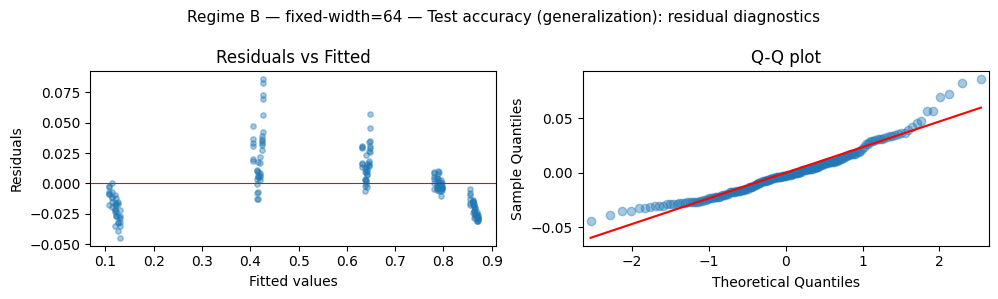


  Post-hoc Tukey HSD (depth levels, training accuracy):
 A  B      diff
12 16  0.078263
12  2 -0.024097
12  4 -0.049160
12  6 -0.050627
12  8 -0.045003
16  2 -0.102360
16  4 -0.127423
16  6 -0.128890
16  8 -0.123267
 2  4 -0.025063
 2  6 -0.026530
 2  8 -0.020907
 4  6 -0.001467
 4  8  0.004157
 6  8  0.005623

  Regime B — fixed-width=128

  Outcome: Training accuracy (capacity)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source         F  partial_eta2
           depth_cat  7.611910      0.202380
            corr_cat 13.416603      0.263502
depth_cat * corr_cat  4.391528      0.369299
            Residual       NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.1013
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.994408  0.001755  566.626026  6.062722e-289
depth_log             0.001267  0.000611    2.074123   3.952367e-02
corruption            0.012667  0.003248    3.900266   1.365502e-

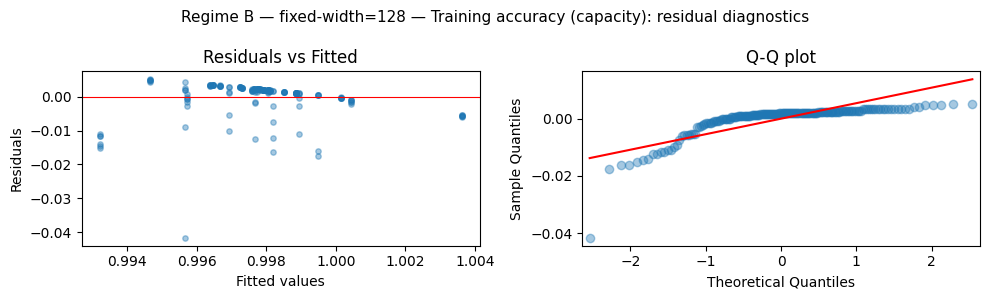


  Outcome: Test accuracy (generalization)
  n = 180
  Shapiro-Wilk p = 0.0000 (non-normal)

  Two-way ANOVA:
              Source            F  partial_eta2
           depth_cat     8.762577      0.226058
            corr_cat 73675.251587      0.999491
depth_cat * corr_cat     3.977563      0.346551
            Residual          NaN           NaN

  OLS regression (depth on log2 scale):
  R² = 0.9915
                         Coef.  Std.Err.           t          P>|t|
Intercept             0.878299  0.008304  105.761895  3.224262e-161
depth_log             0.001050  0.002890    0.363324   7.167989e-01
corruption           -0.759140  0.015368  -49.396953  4.422281e-105
depth_log:corruption -0.001000  0.005349   -0.186909   8.519474e-01


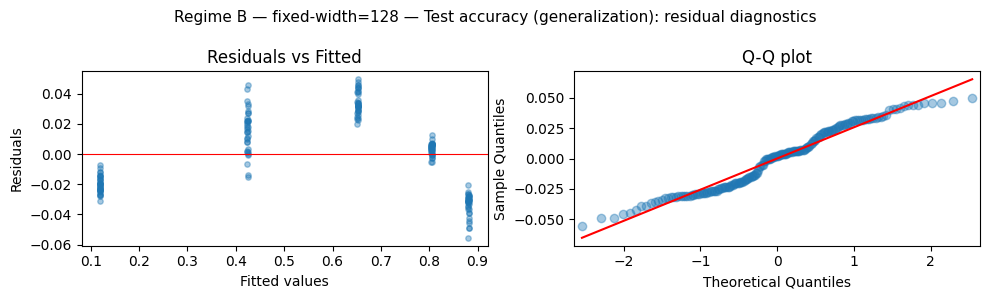


  Post-hoc Tukey HSD (depth levels, training accuracy):
 A  B      diff
12 16  0.005487
12  2  0.002107
12  4  0.000143
12  6  0.000117
12  8  0.000813
16  2 -0.003380
16  4 -0.005343
16  6 -0.005370
16  8 -0.004673
 2  4 -0.001963
 2  6 -0.001990
 2  8 -0.001293
 4  6 -0.000027
 4  8  0.000670
 6  8  0.000697


In [ ]:
def run_anova_block(df_sub, label):
    """
    Two-way ANOVA: Accuracy ~ Depth + Corruption + Depth:Corruption
    Reports F-stats, p-values, and partial eta-squared (η²p) for each factor.
    Also reports OLS with crossover analysis (v2: uses 6-point depth grid).
    """
    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')

    for target_col, target_name in [('final_train_acc', 'Training accuracy (capacity)'),
                                     ('final_test_acc',  'Test accuracy (generalization)')]:
        print(f'\n  Outcome: {target_name}')
        print(f'  n = {len(df_sub)}')

        _, p_norm = stats.shapiro(df_sub[target_col])
        print(f'  Shapiro-Wilk p = {p_norm:.4f} '
              f'({"non-normal" if p_norm < 0.05 else "normal"})')

        df_sub = df_sub.copy()
        df_sub['depth_cat'] = df_sub['depth'].astype(str)
        df_sub['corr_cat']  = df_sub['corruption'].astype(str)

        aov = pg.anova(data=df_sub, dv=target_col,
                       between=['depth_cat', 'corr_cat'], detailed=True)
        print('\n  Two-way ANOVA:')
        if 'p-unc' in aov.columns:
            print(aov[['Source','F','p-unc','np2']].rename(
                  columns={'p-unc': 'p_value', 'np2': 'partial_eta2'}).to_string(index=False))
        else:
            print(aov[['Source','F','np2']].rename(
                  columns={'np2': 'partial_eta2'}).to_string(index=False))

        # OLS — log2(depth) × corruption interaction
        df_sub['depth_log'] = np.log2(df_sub['depth'])
        model_ols = smf.ols(
            f'{target_col} ~ depth_log * corruption + C(regime)', data=df_sub
        ).fit()
        print(f'\n  OLS regression (depth on log2 scale):')
        print(f'  R² = {model_ols.rsquared:.4f}')
        print(model_ols.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

        # Residual diagnostics
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        fig.suptitle(f'{label} — {target_name}: residual diagnostics', fontsize=11)
        residuals = model_ols.resid
        fitted    = model_ols.fittedvalues
        axes[0].scatter(fitted, residuals, alpha=0.4, s=15)
        axes[0].axhline(0, color='red', linewidth=0.8)
        axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
        axes[0].set_title('Residuals vs Fitted')
        sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
        axes[1].set_title('Q-Q plot')
        plt.tight_layout(); plt.show()

    # Post-hoc Tukey HSD on depth (train acc)
    print('\n  Post-hoc Tukey HSD (depth levels, training accuracy):')
    ph = pg.pairwise_tukey(data=df_sub, dv='final_train_acc', between='depth_cat')
    cols = ['A','B','diff','p-tukey'] if 'p-tukey' in ph.columns else ['A','B','diff']
    print(ph[cols].to_string(index=False))


# Run analysis for each regime × budget/width combination
for budget in PARAM_BUDGETS:
    sub = df[(df['regime'] == 'iso_param') & (df['budget'] == budget)]
    if len(sub) > 0:
        run_anova_block(sub, f'Regime A — iso-parameter budget={budget:,}')

for width in FIXED_WIDTHS:
    sub = df[(df['regime'] == 'fixed_width') & (df['fixed_w'] == width)]
    if len(sub) > 0:
        run_anova_block(sub, f'Regime B — fixed-width={width}')

## 9. v2 crossover analysis
*New in v2 — uses the 6-point depth grid to find where the capacity cliff begins.*

In [ ]:
# ── Crossover depth analysis ─────────────────────────────────────────────────
# v2 addition: with depths [2,4,6,8,12,16] we can estimate the crossover point
# where additional depth starts hurting. We fit a piecewise linear model to
# mean train accuracy vs log2(depth) for each corruption level and report
# the estimated breakpoint.

from scipy.optimize import minimize_scalar

def piecewise_fit_R2(breakpoint_log2, x_log2, y):
    """Fit two-segment linear model at given breakpoint, return negative R²."""
    left  = x_log2 <= breakpoint_log2
    right = ~left
    if left.sum() < 2 or right.sum() < 2:
        return 0  # not enough points
    def seg_ss(mask):
        xm, ym = x_log2[mask], y[mask]
        coef = np.polyfit(xm, ym, 1)
        return np.sum((ym - np.polyval(coef, xm))**2)
    ss_resid = seg_ss(left) + seg_ss(right)
    ss_total = np.sum((y - y.mean())**2)
    return 1 - ss_resid / ss_total if ss_total > 0 else 0


print('Crossover depth analysis (v2)')
print('='*55)
print(f'  Searching breakpoints in log2 space across depths {DEPTHS}')
print()

crossover_records = []
for corruption in CORRUPTION_RATES:
    for regime in df['regime'].unique():
        sub = df[(df['corruption'] == corruption) & (df['regime'] == regime)]
        if len(sub) < len(DEPTHS) * 2:
            continue
        agg = sub.groupby('depth')['final_train_acc'].mean().reset_index()
        x = np.log2(agg['depth'].values).astype(float)
        y = agg['final_train_acc'].values.astype(float)

        # Grid search for best breakpoint in log2 space
        best_bp, best_r2 = None, -np.inf
        for bp in np.linspace(x.min() + 0.3, x.max() - 0.3, 50):
            r2 = piecewise_fit_R2(bp, x, y)
            if r2 > best_r2:
                best_r2, best_bp = r2, bp

        crossover_depth = round(2 ** best_bp, 1) if best_bp else None

        # Direction of each segment
        left_mask  = x <= best_bp
        right_mask = ~left_mask
        left_slope  = np.polyfit(x[left_mask],  y[left_mask],  1)[0] if left_mask.sum() >= 2 else None
        right_slope = np.polyfit(x[right_mask], y[right_mask], 1)[0] if right_mask.sum() >= 2 else None

        crossover_records.append({
            'regime':          regime,
            'corruption':      corruption,
            'crossover_depth': crossover_depth,
            'piecewise_R2':    round(best_r2, 3),
            'left_slope':      round(left_slope, 4) if left_slope is not None else None,
            'right_slope':     round(right_slope, 4) if right_slope is not None else None,
        })

df_cross = pd.DataFrame(crossover_records)
print(df_cross.to_string(index=False))
df_cross.to_csv('results_crossover_v2.csv', index=False)
print('\nSaved results_crossover_v2.csv')
print()
print('Interpretation:')
print('  crossover_depth = estimated depth where capacity stops increasing')
print('  left_slope > 0  = accuracy improving before crossover')
print('  right_slope < 0 = accuracy declining after crossover')

Crossover depth analysis (v2)
  Searching breakpoints in log2 space across depths [2, 4, 6, 8, 12, 16]

     regime  corruption  crossover_depth  piecewise_R2  left_slope  right_slope
  iso_param         0.0              8.1         0.765      0.0002      -0.0038
fixed_width         0.0              8.1         0.918      0.0015      -0.0038
  iso_param         0.1              8.1         0.989      0.0001      -0.0455
fixed_width         0.1              8.1         0.997      0.0004      -0.0146
  iso_param         0.3              8.1         0.993     -0.0056      -0.1223
fixed_width         0.3              8.1         0.985      0.0038      -0.0599
  iso_param         0.6              8.1         0.991     -0.0125      -0.2551
fixed_width         0.6              8.1         0.982      0.0103      -0.1373
  iso_param         1.0              8.1         0.995     -0.0174      -0.5244
fixed_width         1.0              8.1         0.989      0.0145      -0.2889

Saved results_c

## 10. Visualizations

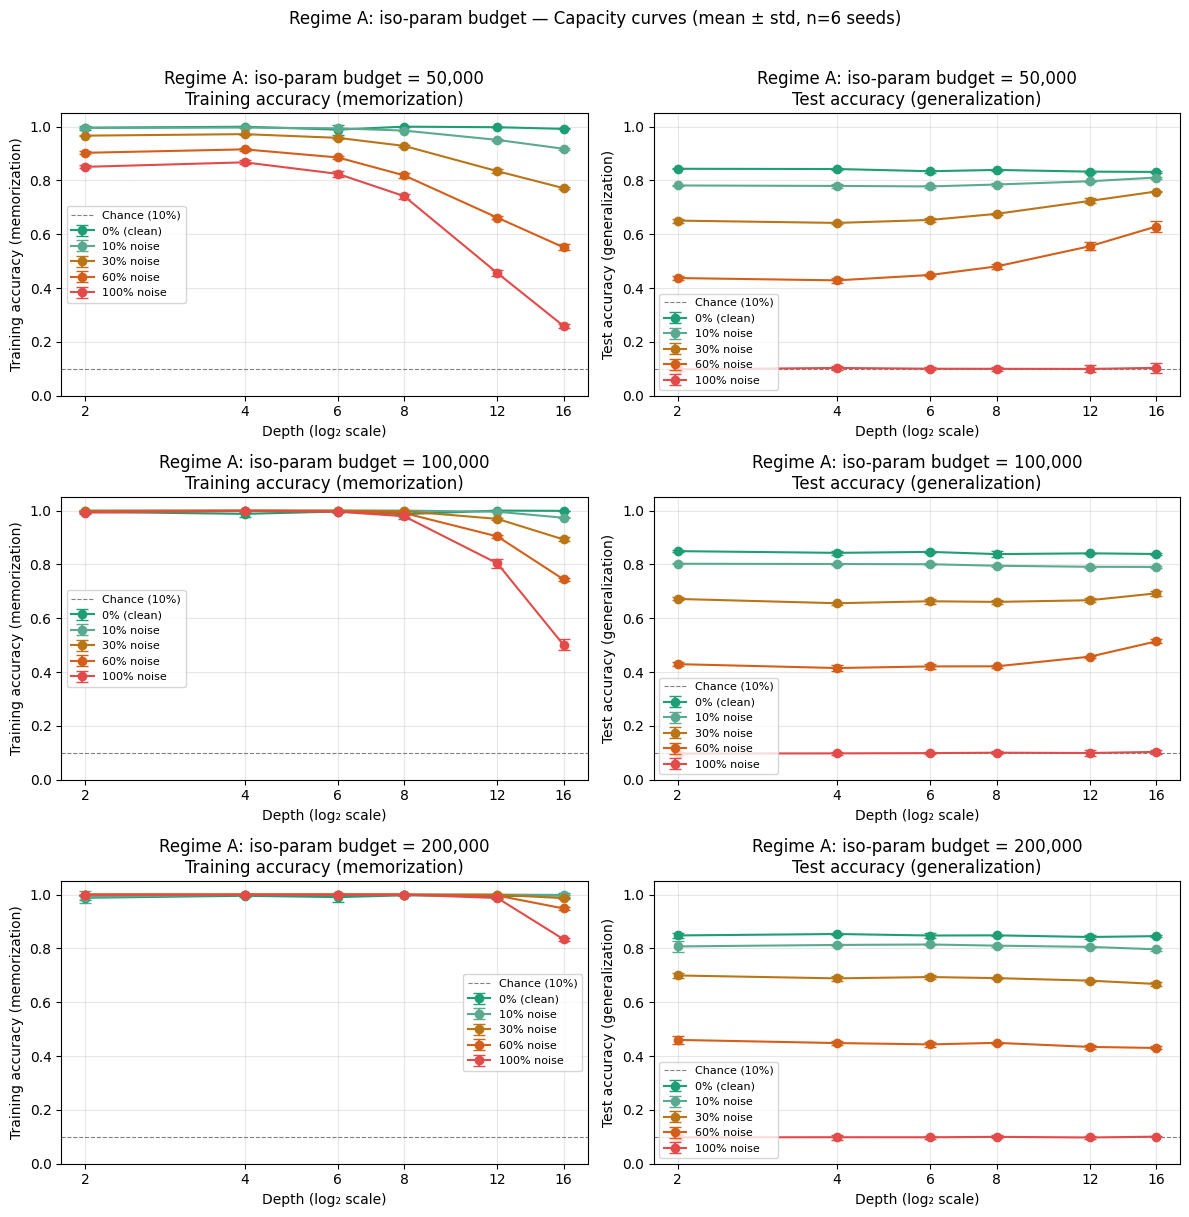

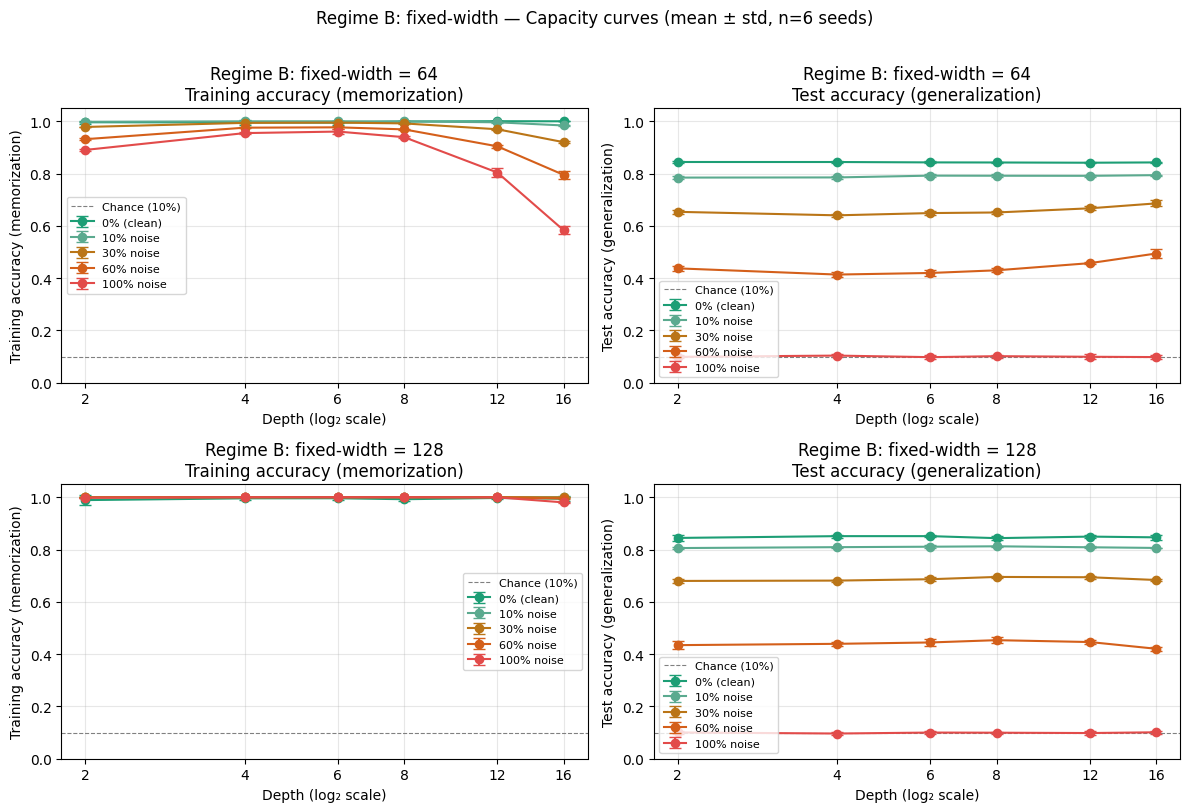

In [ ]:
CORR_LABELS = {0.0: '0% (clean)', 0.1: '10% noise', 0.3: '30% noise',
               0.6: '60% noise', 1.0: '100% noise'}
PALETTE = {0.0: '#1D9E75', 0.1: '#5BAA8F', 0.3: '#BA7517',
           0.6: '#D45F1A', 1.0: '#E24B4A'}


def plot_capacity_curves(df_sub, regime_label, group_col, group_vals, out_fname=None):
    """
    For each group (budget or fixed_width), plot:
    - Left:  training accuracy vs depth (by corruption rate)
    - Right: test accuracy vs depth (by corruption rate)
    Error bars = ±1 std across seeds.
    v2: x-axis now covers [2,4,6,8,12,16] — shows the crossover region.
    """
    n_groups = len(group_vals)
    fig, axes = plt.subplots(n_groups, 2, figsize=(12, 4 * n_groups))
    if n_groups == 1:
        axes = axes[np.newaxis, :]

    for i, gval in enumerate(group_vals):
        sub = df_sub[df_sub[group_col] == gval]
        group_tag = f'{regime_label} = {gval:,}' if isinstance(gval, int) else str(gval)

        for j, (metric, metric_name) in enumerate([
                ('final_train_acc', 'Training accuracy (memorization)'),
                ('final_test_acc',  'Test accuracy (generalization)')]):

            ax = axes[i, j]
            for corr in CORRUPTION_RATES:
                c_sub = sub[sub['corruption'] == corr]
                agg = c_sub.groupby('depth')[metric].agg(['mean','std']).reset_index()
                ax.errorbar(agg['depth'], agg['mean'], yerr=agg['std'],
                            marker='o', label=CORR_LABELS[corr],
                            color=PALETTE[corr], capsize=4, linewidth=1.5)

            ax.set_xscale('log', base=2)
            ax.set_xticks(DEPTHS)
            ax.set_xticklabels(DEPTHS)
            ax.set_xlabel('Depth (log₂ scale)')
            ax.set_ylabel(metric_name)
            ax.set_title(f'{group_tag}\n{metric_name}')
            ax.set_ylim(0, 1.05)
            ax.axhline(1/N_CLASSES, color='gray', linestyle='--',
                       linewidth=0.8, label='Chance (10%)')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'{regime_label} — Capacity curves (mean ± std, n={len(SEEDS)} seeds)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if out_fname:
        plt.savefig(out_fname, dpi=150, bbox_inches='tight')
    plt.show()


# Regime A
plot_capacity_curves(df[df['regime']=='iso_param'],
                     'Regime A: iso-param budget', 'budget', PARAM_BUDGETS,
                     'fig_regimeA_capacity_v2.png')

# Regime B
plot_capacity_curves(df[df['regime']=='fixed_width'],
                     'Regime B: fixed-width', 'fixed_w', FIXED_WIDTHS,
                     'fig_regimeB_capacity_v2.png')

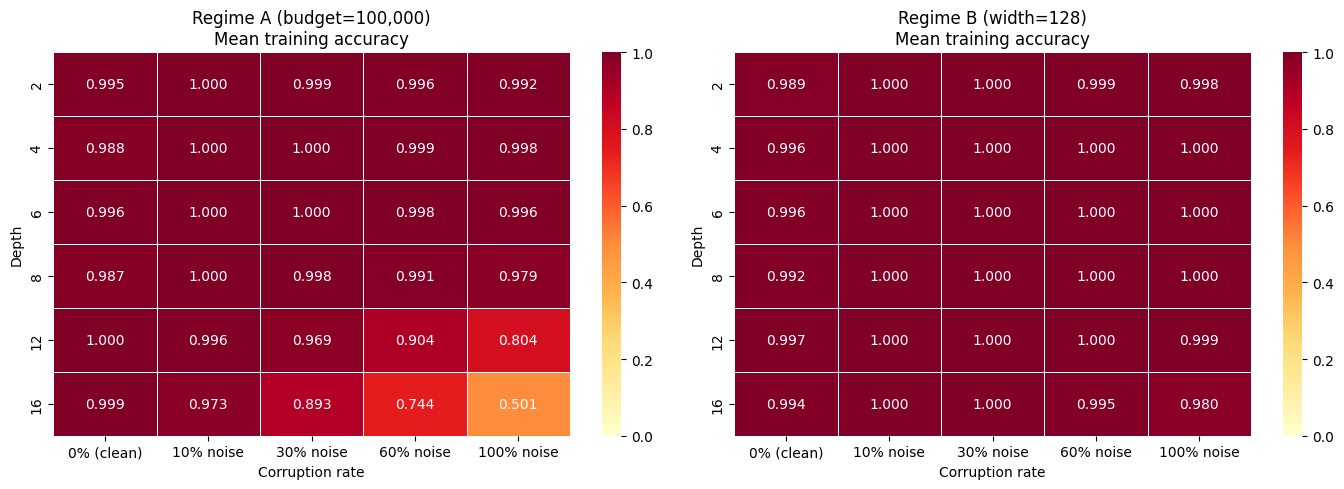

In [ ]:
# ── Heatmap: mean train accuracy across depth × corruption ───────────────────
# v2: shows all 6 depths on y-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (regime, group_col, gval, label) in zip(axes, [
        ('iso_param',   'budget',  PARAM_BUDGETS[1], f'Regime A (budget={PARAM_BUDGETS[1]:,})'),
        ('fixed_width', 'fixed_w', FIXED_WIDTHS[1],  f'Regime B (width={FIXED_WIDTHS[1]})')]):

    sub = df[(df['regime']==regime) & (df[group_col]==gval)]
    pivot = sub.groupby(['depth','corruption'])['final_train_acc'].mean().unstack()
    pivot.columns = [CORR_LABELS[c] for c in pivot.columns]

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f'{label}\nMean training accuracy')
    ax.set_xlabel('Corruption rate')
    ax.set_ylabel('Depth')

plt.tight_layout()
plt.savefig('fig_heatmap_train_acc_v2.png', dpi=150, bbox_inches='tight')
plt.show()

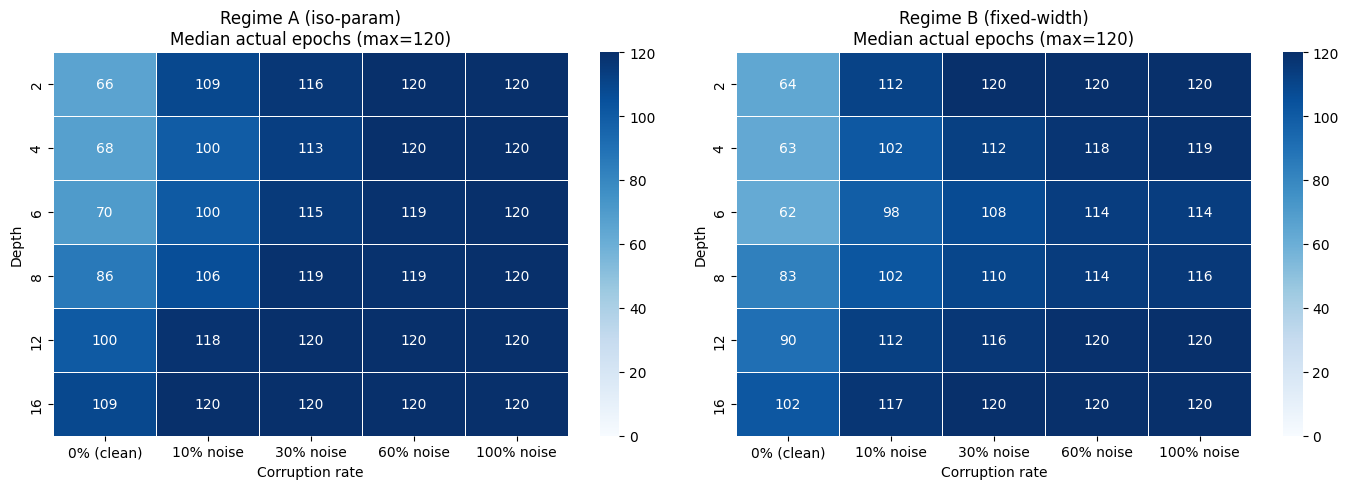

Interpretation: cells near MAX_EPOCHS = still converging at cutoff. Low values = early stopped (fast convergence or collapse).


In [ ]:
# ── v2 new: early stopping epochs by depth × corruption ─────────────────────
# Shows how many epochs each condition actually needed — validates the
# early stopping design and reveals which conditions collapse fast.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, regime in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime']==regime]
    pivot_ep = sub.groupby(['depth','corruption'])['actual_epochs'].median().unstack()
    pivot_ep.columns = [CORR_LABELS[c] for c in pivot_ep.columns]
    sns.heatmap(pivot_ep, annot=True, fmt='.0f', cmap='Blues',
                vmin=0, vmax=MAX_EPOCHS, ax=ax, linewidths=0.5)
    ax.set_title(f'Regime {"A (iso-param)" if regime=="iso_param" else "B (fixed-width)"}\n'
                 f'Median actual epochs (max={MAX_EPOCHS})')
    ax.set_xlabel('Corruption rate')
    ax.set_ylabel('Depth')

plt.tight_layout()
plt.savefig('fig_actual_epochs_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: cells near MAX_EPOCHS = still converging at cutoff. '
      'Low values = early stopped (fast convergence or collapse).')

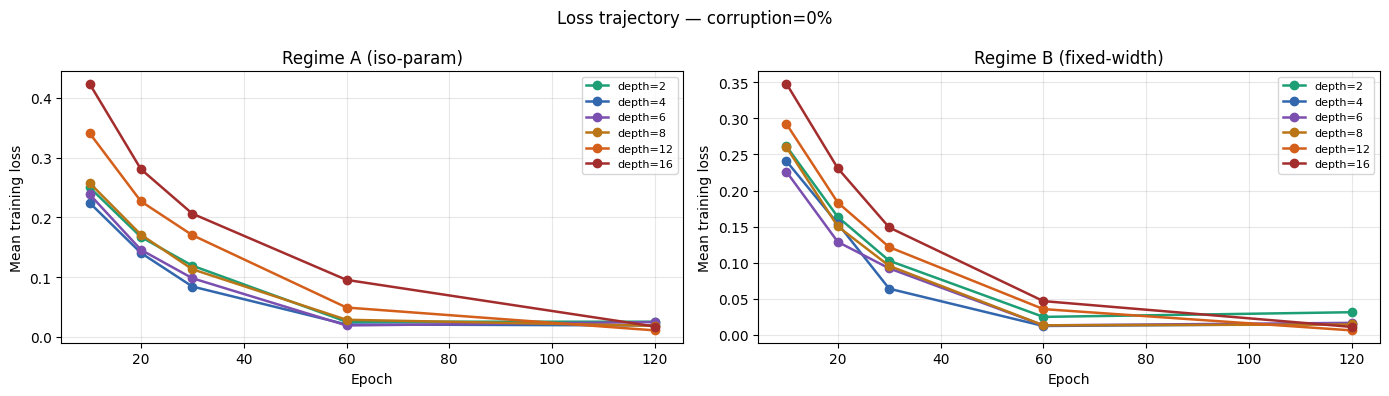

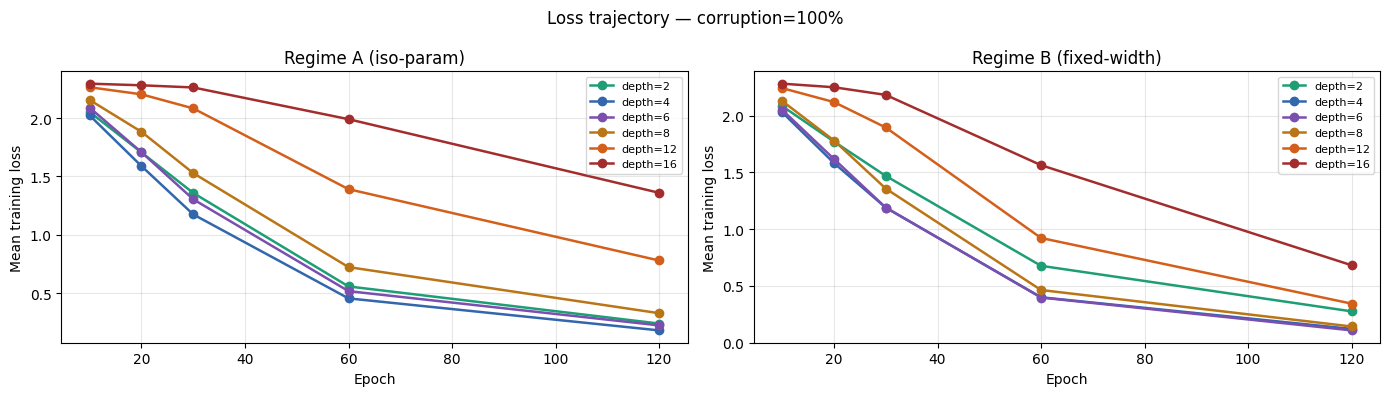

In [ ]:
# ── v2 new: loss trajectory by depth (clean data) ───────────────────────────
# Plots training loss at snapshot epochs for each depth level.
# On clean data (corruption=0) this shows pure convergence speed.
# On 100% noise it reveals whether deep models memorize or give up.

snap_cols = [f'loss_ep{ep}' for ep in LOSS_SNAP_EPOCHS] + ['final_train_loss']
snap_x    = LOSS_SNAP_EPOCHS + [MAX_EPOCHS]  # approximate — actual may differ

depth_colors = {2: '#1D9E75', 4: '#3266ad', 6: '#7B4FAF',
                8: '#BA7517', 12: '#D45F1A', 16: '#A32D2D'}

for corruption in [0.0, 1.0]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Loss trajectory — corruption={int(corruption*100)}%', fontsize=12)

    for ax, regime in zip(axes, ['iso_param', 'fixed_width']):
        sub = df[(df['regime']==regime) & (df['corruption']==corruption)]
        for depth in DEPTHS:
            d_sub = sub[sub['depth']==depth]
            if len(d_sub) == 0:
                continue
            # Mean loss at each snapshot across seeds
            ys = [d_sub[col].mean() for col in snap_cols if col in d_sub.columns]
            xs = snap_x[:len(ys)]
            ax.plot(xs, ys, marker='o', label=f'depth={depth}',
                    color=depth_colors[depth], linewidth=1.8)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Mean training loss')
        ax.set_title(f'Regime {"A (iso-param)" if regime=="iso_param" else "B (fixed-width)"}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'fig_loss_trajectory_corr{int(corruption*100)}_v2.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

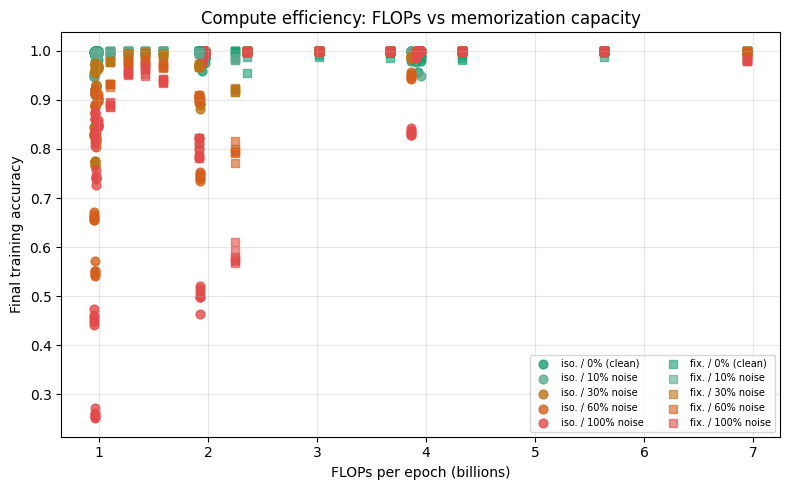

In [ ]:
# ── Secondary: FLOPs vs capacity ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for regime, marker, alpha in [('iso_param', 'o', 0.8), ('fixed_width', 's', 0.6)]:
    sub = df[df['regime']==regime]
    for corr in CORRUPTION_RATES:
        c_sub = sub[sub['corruption']==corr]
        ax.scatter(c_sub['flops_per_epoch'] / 1e9,
                   c_sub['final_train_acc'],
                   c=PALETTE[corr], marker=marker, alpha=alpha, s=40,
                   label=f'{regime[:3]}. / {CORR_LABELS[corr]}')

ax.set_xlabel('FLOPs per epoch (billions)')
ax.set_ylabel('Final training accuracy')
ax.set_title('Compute efficiency: FLOPs vs memorization capacity')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_flops_vs_capacity_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary tables

In [ ]:
summary = df.groupby(['regime', 'depth', 'corruption']).agg(
    mean_train_acc  =('final_train_acc',  'mean'),
    std_train_acc   =('final_train_acc',  'std'),
    mean_test_acc   =('final_test_acc',   'mean'),
    std_test_acc    =('final_test_acc',   'std'),
    median_epochs   =('actual_epochs',    'median'),  # v2: stopping epoch info
    n_runs          =('final_train_acc',  'count'),
).round(4).reset_index()

print(f'Optimization failures excluded: {len(df_fail)}')
print(f'Valid runs in summary: {len(df)}')
print()
print(summary.to_string(index=False))
summary.to_csv('results_summary_table_v2.csv', index=False)
print('\nSaved results_summary_table_v2.csv')

Optimization failures excluded: 8
Valid runs in summary: 900

     regime  depth  corruption  mean_train_acc  std_train_acc  mean_test_acc  std_test_acc  median_epochs  n_runs
fixed_width      2         0.0          0.9925         0.0132         0.8441        0.0076           64.0      12
fixed_width      2         0.1          0.9989         0.0012         0.7950        0.0119          111.5      12
fixed_width      2         0.3          0.9888         0.0113         0.6667        0.0157          120.0      12
fixed_width      2         0.6          0.9652         0.0355         0.4358        0.0122          120.0      12
fixed_width      2         1.0          0.9440         0.0564         0.0998        0.0051          120.0      12
fixed_width      4         0.0          0.9956         0.0071         0.8476        0.0059           63.0      12
fixed_width      4         0.1          0.9998         0.0003         0.7970        0.0129          101.5      12
fixed_width      4        

## 12. Download all outputs

In [ ]:
from google.colab import files
import glob

outputs = sorted(glob.glob('*.csv') + glob.glob('*.png'))
print(f'Downloading {len(outputs)} files...')
for f_path in outputs:
    print(f'  {f_path}')
    files.download(f_path)

  fig_actual_epochs_v2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  fig_flops_vs_capacity_v2.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  results_summary_table_v2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>